In [1]:
import importlib, subprocess, sys

REQUIRED = {'ultralytics': 'ultralytics>=8.3.0', 'cv2': 'opencv-python', 'tqdm': 'tqdm', 'pandas': 'pandas', 'requests': 'requests'}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

In [2]:
import os, json, glob, shutil, time, random
from pathlib import Path
from collections import Counter

import numpy as np
import cv2
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

random.seed(0); np.random.seed(0); torch.manual_seed(0)

device = 0 if torch.cuda.is_available() else 'cpu'
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 7.6 GB


In [3]:
LAB = Path(os.getcwd()).resolve()
if LAB.name != 'lab-6':
    cand = LAB / 'lab-6'
    if cand.exists():
        LAB = cand.resolve()
DATA = LAB / 'data'
RTSD_DIR = DATA / 'rtsd'
YOLO_DIR = DATA / 'rtsd_yolo'
REAL_DIR = DATA / 'real_photos'
RUNS_DIR = LAB / 'runs'
RESULTS_PATH = LAB / 'results.json'

for p in [RTSD_DIR, YOLO_DIR/'images'/'train', YOLO_DIR/'images'/'val', YOLO_DIR/'labels'/'train', YOLO_DIR/'labels'/'val']:
    p.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

SUPER_NAMES = ['warning', 'priority', 'prohibitory', 'mandatory', 'special', 'informational', 'service', 'additional']
SUPER_RU = ['Предупреждающие', 'Приоритета', 'Запрещающие', 'Предписывающие', 'Особых_предписаний', 'Информационные', 'Сервиса', 'Доп_информации']
NUM_CLASSES = len(SUPER_NAMES)


def sign_to_super(sign_class):
    s = str(sign_class).strip()
    if not s or s.lower() == 'nan':
        return -1
    head = s.split('.')[0].split('_')[0]
    try:
        d = int(head)
        return d - 1 if 1 <= d <= 8 else -1
    except ValueError:
        return -1


print('LAB:', LAB)
for i, (n, ru) in enumerate(zip(SUPER_NAMES, SUPER_RU)):
    print(f'  {i}  {n:14}  {ru}')

LAB: /mnt/data/itmo-cv/lab-6
  0  warning         Предупреждающие
  1  priority        Приоритета
  2  prohibitory     Запрещающие
  3  mandatory       Предписывающие
  4  special         Особых_предписаний
  5  informational   Информационные
  6  service         Сервиса
  7  additional      Доп_информации


In [4]:
def find_rtsd():
    jsons = sorted(p for p in Path(RTSD_DIR).rglob('*.json') if 'label_map' not in p.name.lower())
    best_dir, best_n = None, 0
    for d in Path(RTSD_DIR).rglob('*'):
        if not d.is_dir():
            continue
        n = sum(1 for _ in d.glob('*.jpg')) + sum(1 for _ in d.glob('*.png'))
        if n > best_n:
            best_n, best_dir = n, d
    return (best_dir if best_n >= 100 else None), jsons


frames_dir, json_files = find_rtsd()
if frames_dir and json_files:
    n_frames = sum(1 for _ in frames_dir.glob('*.jpg')) + sum(1 for _ in frames_dir.glob('*.png'))
    print(f'frames: {frames_dir} ({n_frames} images)')
    print(f'jsons:  {[p.name for p in json_files]}')
else:
    raise SystemExit(f'RTSD not found. Run: kaggle datasets download -d watchman/rtsd-dataset -p {RTSD_DIR} --unzip')

frames: /mnt/data/itmo-cv/lab-6/data/rtsd/rtsd-frames/rtsd-frames (179138 images)
jsons:  ['train_anno.json', 'train_anno_reduced.json', 'val_anno.json']


In [5]:
def parse_rtsd_json(json_path, split_label):
    d = json.load(open(json_path))
    cat_map = {c['id']: c['name'] for c in d['categories']}
    img_map = {im['id']: im for im in d['images']}
    rows = []
    for ann in d['annotations']:
        info = img_map.get(ann['image_id'])
        cat_name = cat_map.get(ann['category_id'])
        if not info or not cat_name:
            continue
        sup = sign_to_super(cat_name)
        if sup < 0:
            continue
        x, y, w, h = ann['bbox']
        rows.append({
            'filename': info['file_name'],
            'x1': float(x), 'y1': float(y),
            'x2': float(x) + float(w), 'y2': float(y) + float(h),
            'sign_class': cat_name, 'super': sup, 'split': split_label,
        })
    return pd.DataFrame(rows)


train_jsons = [p for p in json_files if 'train' in p.name.lower() and 'reduced' not in p.name.lower()]
val_jsons = [p for p in json_files if 'val' in p.name.lower() or 'test' in p.name.lower()]

dfs = []
for p in train_jsons:
    print(f'parsing TRAIN {p.name}')
    dfs.append(parse_rtsd_json(p, 'train'))
for p in val_jsons:
    print(f'parsing VAL   {p.name}')
    dfs.append(parse_rtsd_json(p, 'val'))
ann = pd.concat(dfs, ignore_index=True).drop_duplicates(subset=['filename', 'x1', 'y1', 'x2', 'y2', 'super'])

print(f'\nTotal annotations: {len(ann)} (train={len(ann[ann.split=="train"])}, val={len(ann[ann.split=="val"])})')
print('Per super-class:')
for c, n in ann['super'].value_counts().sort_index().items():
    print(f'  {c} {SUPER_NAMES[c]:14} {n}')

parsing TRAIN train_anno.json


parsing VAL   val_anno.json

Total annotations: 104358 (train=95492, val=8866)
Per super-class:
  0 warning        9998
  1 priority       18328
  2 prohibitory    13642
  3 mandatory      7858
  4 special        45061
  5 informational  3713
  6 service        2363
  7 additional     3395


In [6]:
frame_index = {}
for ext in ('*.jpg', '*.JPG', '*.jpeg', '*.png', '*.PNG'):
    for p in Path(frames_dir).rglob(ext):
        frame_index[p.name] = p
        frame_index[p.stem] = p
print(f'frames index: {len(frame_index)} entries')


def resolve_image_path(filename):
    bn = os.path.basename(str(filename))
    if bn in frame_index:
        return frame_index[bn]
    stem = os.path.splitext(bn)[0]
    return frame_index.get(stem)


ann['path'] = ann['filename'].apply(resolve_image_path)
missing = ann['path'].isna().sum()
print(f'dropped (image not on disk): {missing}')
ann = ann.dropna(subset=['path']).reset_index(drop=True)
print(f'annotations: {len(ann)}')

frames index: 358276 entries
dropped (image not on disk): 0
annotations: 104358


In [7]:
TRAIN_TARGET = 30000
VAL_TARGET = 1500

tr_pool = sorted(set(ann[ann['split']=='train']['filename'].tolist()))
va_pool = sorted(set(ann[ann['split']=='val']['filename'].tolist()))
print(f'available: train={len(tr_pool)}, val={len(va_pool)}')

rng_s = random.Random(0)
if not va_pool:
    rng_s.shuffle(tr_pool)
    val_set = set(tr_pool[:VAL_TARGET])
    train_set = set(tr_pool[VAL_TARGET:VAL_TARGET + TRAIN_TARGET])
else:
    train_set = set(rng_s.sample(tr_pool, min(TRAIN_TARGET, len(tr_pool))))
    val_set = set(rng_s.sample(va_pool, min(VAL_TARGET, len(va_pool))))

print(f'TRAIN: {len(train_set)} | VAL: {len(val_set)}')


def class_dist(filename_set):
    cc = Counter()
    for _, r in ann[ann['filename'].isin(filename_set)].iterrows():
        cc[int(r['super'])] += 1
    return cc


tr_dist, va_dist = class_dist(train_set), class_dist(val_set)
print('\nclass distribution (instance count):')
for c in range(NUM_CLASSES):
    print(f'  {c} {SUPER_NAMES[c]:14}  train={tr_dist[c]:>7}  val={va_dist[c]:>5}')

available: train=54188, val=5000
TRAIN: 30000 | VAL: 1500



class distribution (instance count):
  0 warning         train=   5163  val=  273
  1 priority        train=   9284  val=  476
  2 prohibitory     train=   6917  val=  352
  3 mandatory       train=   3869  val=  184
  4 special         train=  22784  val= 1190
  5 informational   train=   1850  val=  102
  6 service         train=   1182  val=   69
  7 additional      train=   1686  val=   84


In [8]:
def link_or_copy(src, dst):
    src, dst = str(src), str(dst)
    if os.path.exists(dst):
        return
    for op in (os.symlink, os.link):
        try:
            op(src, dst); return
        except (OSError, NotImplementedError):
            continue
    shutil.copy2(src, dst)


def write_yolo_seg(img_path, sub_df, out_lbl_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return False, 0
    H, W = img.shape[:2]
    lines = []
    for _, r in sub_df.iterrows():
        cls = int(r['super'])
        x1 = max(0, min(W - 1, float(r['x1']))); x2 = max(0, min(W - 1, float(r['x2'])))
        y1 = max(0, min(H - 1, float(r['y1']))); y2 = max(0, min(H - 1, float(r['y2'])))
        if x2 - x1 < 2 or y2 - y1 < 2:
            continue
        coords = []
        for x, y in [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]:
            coords.append(min(max(x / W, 0.0), 1.0))
            coords.append(min(max(y / H, 0.0), 1.0))
        lines.append(f'{cls} ' + ' '.join(f'{c:.6f}' for c in coords))
    out_lbl_path = Path(out_lbl_path)
    out_lbl_path.parent.mkdir(parents=True, exist_ok=True)
    out_lbl_path.write_text('\n'.join(lines))
    return True, len(lines)


def convert_subset(filenames, img_dst, lbl_dst, ann_by_file):
    n_ok = n_skip = n_inst = 0
    for fn in tqdm(filenames):
        sub = ann_by_file.get_group(fn) if fn in ann_by_file.groups else None
        if sub is None or len(sub) == 0:
            n_skip += 1; continue
        src = sub.iloc[0]['path']
        out_lbl = Path(lbl_dst) / (Path(fn).stem + '.txt')
        ok, cnt = write_yolo_seg(src, sub, out_lbl)
        if not ok:
            n_skip += 1; continue
        link_or_copy(src, Path(img_dst) / Path(fn).name)
        n_ok += 1; n_inst += cnt
    return n_ok, n_skip, n_inst


_existing_tr = len(list((YOLO_DIR/'labels'/'train').glob('*.txt'))) if (YOLO_DIR/'labels'/'train').exists() else 0
_existing_va = len(list((YOLO_DIR/'labels'/'val').glob('*.txt'))) if (YOLO_DIR/'labels'/'val').exists() else 0

if _existing_tr > 100 and _existing_va > 100:
    tr_ok, va_ok = _existing_tr, _existing_va
    tr_inst = sum(len(open(p).read().splitlines()) for p in (YOLO_DIR/'labels'/'train').glob('*.txt'))
    va_inst = sum(len(open(p).read().splitlines()) for p in (YOLO_DIR/'labels'/'val').glob('*.txt'))
    print(f'[skip] already converted: train={tr_ok} ({tr_inst} inst), val={va_ok} ({va_inst} inst)')
else:
    ann_by_file = ann.groupby('filename')
    t0 = time.time()
    tr_ok, _, tr_inst = convert_subset(list(train_set), YOLO_DIR/'images'/'train', YOLO_DIR/'labels'/'train', ann_by_file)
    va_ok, _, va_inst = convert_subset(list(val_set), YOLO_DIR/'images'/'val', YOLO_DIR/'labels'/'val', ann_by_file)
    print(f'\nTRAIN: {tr_ok} images, {tr_inst} instances')
    print(f'VAL:   {va_ok} images, {va_inst} instances')
    print(f'conversion: {time.time() - t0:.1f}s')

[skip] already converted: train=30000 (52735 inst), val=1500 (2730 inst)


In [9]:
data_yaml = YOLO_DIR / 'data.yaml'
data_yaml.write_text(
    f'path: {YOLO_DIR}\n'
    f'train: images/train\n'
    f'val: images/val\n'
    f'nc: {NUM_CLASSES}\n'
    f'names: {json.dumps(SUPER_NAMES)}\n'
)
print(data_yaml.read_text())

path: /mnt/data/itmo-cv/lab-6/data/rtsd_yolo
train: images/train
val: images/val
nc: 8
names: ["warning", "priority", "prohibitory", "mandatory", "special", "informational", "service", "additional"]



In [10]:
MODEL_NAME = 'yolo11s-seg.pt'
EPOCHS = 80
IMG_SIZE = 640
BATCH = 16
PATIENCE = 20
SAVE_PERIOD = 3
RUN_NAME = 'rtsd_yolo11s'

best_pt = RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'
results_csv = RUNS_DIR / RUN_NAME / 'results.csv'

if best_pt.exists() and results_csv.exists():
    print(f'[skip train] using existing {best_pt}')
    lines = [ln for ln in results_csv.read_text().splitlines() if ln.strip()]
    training_seconds = float(lines[-1].split(',')[1]) if len(lines) > 1 else 0.0
    epochs_done = max(0, len(lines) - 1)
    print(f'epochs done: {epochs_done}, time: {training_seconds/60:.1f} min')
    train_results = None
else:
    model = YOLO(MODEL_NAME)
    t_start = time.time()
    train_results = model.train(
        data=str(data_yaml), epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH,
        patience=PATIENCE, cache='disk', amp=True, device=device,
        project=str(RUNS_DIR), name=RUN_NAME, exist_ok=True,
        plots=True, verbose=True, seed=0, save_period=SAVE_PERIOD, workers=4,
    )
    training_seconds = time.time() - t_start
    print(f'\ntraining: {training_seconds/60:.1f} min')
    best_pt = Path(train_results.save_dir) / 'weights' / 'best.pt'

print('best:', best_pt)

[skip train] using existing /mnt/data/itmo-cv/lab-6/runs/rtsd_yolo11s/weights/best.pt
epochs done: 63, time: 411.6 min
best: /mnt/data/itmo-cv/lab-6/runs/rtsd_yolo11s/weights/best.pt


In [11]:
best_model = YOLO(str(best_pt))
val_metrics = best_model.val(data=str(data_yaml), split='val', imgsz=IMG_SIZE, batch=BATCH, device=device, plots=False, verbose=False)
print('Box mAP50    :', round(float(val_metrics.box.map50), 4))
print('Box mAP50-95 :', round(float(val_metrics.box.map), 4))
print('Mask mAP50   :', round(float(val_metrics.seg.map50), 4))
print('Mask mAP50-95:', round(float(val_metrics.seg.map), 4))
print('\nper-class mask AP50:')
if hasattr(val_metrics.seg, 'ap50') and len(val_metrics.seg.ap50) > 0:
    for i, ap in enumerate(val_metrics.seg.ap50):
        print(f'  {i} {SUPER_NAMES[i]:14}  AP50={float(ap):.3f}')

Ultralytics 8.4.43 🚀 Python-3.12.3 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 SUPER, 7784MiB)


YOLO11s-seg summary (fused): 114 layers, 10,069,912 parameters, 0 gradients, 32.8 GFLOPs


val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 94.4±43.2 MB/s, size: 125.4 KB)


val: Scanning /mnt/data/itmo-cv/lab-6/data/rtsd_yolo/labels/val.cache... 1500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1500/1500 286.0Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 1% ──────────── 1/94 1.1it/s 0.3s<1:26

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 99% ━━━━━━━━━━━╸ 93/94 10.9it/s 8.8s<0.1s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 10.6it/s 8.9s

                   all       1500       2730      0.916      0.892      0.947      0.713      0.789       0.76      0.745      0.277


Speed: 0.3ms preprocess, 3.6ms inference, 0.0ms loss, 0.6ms postprocess per image


Box mAP50    : 0.9466
Box mAP50-95 : 0.7132
Mask mAP50   : 0.7454
Mask mAP50-95: 0.2773

per-class mask AP50:
  0 warning         AP50=0.797
  1 priority        AP50=0.812
  2 prohibitory     AP50=0.681
  3 mandatory       AP50=0.753
  4 special         AP50=0.687
  5 informational   AP50=0.742
  6 service         AP50=0.863
  7 additional      AP50=0.627


In [12]:
def load_yolo_seg_gt(label_path, H, W):
    masks, classes = [], []
    if not os.path.exists(label_path):
        return masks, classes
    for line in open(label_path):
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls = int(parts[0])
        coords = np.asarray([float(x) for x in parts[1:]]).reshape(-1, 2)
        coords[:, 0] *= W; coords[:, 1] *= H
        m = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(m, [coords.astype(np.int32)], 1)
        masks.append(m.astype(bool)); classes.append(cls)
    return masks, classes


def predict_masks(model, img_path, imgsz=640, conf=0.25):
    res = model.predict(str(img_path), imgsz=imgsz, conf=conf, verbose=False, device=device)[0]
    H, W = res.orig_shape
    masks, classes, scores = [], [], []
    if res.masks is not None and len(res.masks) > 0:
        m_arr = res.masks.data.cpu().numpy()
        cls_arr = res.boxes.cls.cpu().numpy().astype(int)
        scr_arr = res.boxes.conf.cpu().numpy()
        for k in range(m_arr.shape[0]):
            m = m_arr[k]
            if m.shape != (H, W):
                m = cv2.resize(m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
            masks.append(m.astype(bool)); classes.append(int(cls_arr[k])); scores.append(float(scr_arr[k]))
    return masks, classes, scores, (H, W)


def iou_pair(a, b):
    inter = np.logical_and(a, b).sum(); union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


def l2_pair(a, b):
    diff = a.astype(np.float32) - b.astype(np.float32)
    return float(np.sqrt((diff * diff).sum()))


def evaluate(model, img_dir, lbl_dir, num_classes, match_iou=0.5, conf=0.25, imgsz=640, require_gt=False):
    img_files = sorted(sum(([str(p) for p in Path(img_dir).glob(f'*{ext}')] for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']), []))
    if require_gt:
        img_files = [ip for ip in img_files
                     if (Path(lbl_dir)/(Path(ip).stem+'.txt')).exists()
                     and (Path(lbl_dir)/(Path(ip).stem+'.txt')).stat().st_size > 0]
    tp = fp = fn = 0
    iou_per_match, l2_per_match, image_mean_iou = [], [], []
    for ip in tqdm(img_files, desc=f'eval {Path(img_dir).name}'):
        H, W = cv2.imread(ip).shape[:2]
        gt_m, gt_c = load_yolo_seg_gt(Path(lbl_dir)/(Path(ip).stem+'.txt'), H, W)
        pr_m, pr_c, _, _ = predict_masks(model, ip, imgsz=imgsz, conf=conf)
        used_pr, used_gt = set(), set()
        per_image_ious = []
        for c in range(num_classes):
            gi = [i for i, x in enumerate(gt_c) if x == c]
            pi = [i for i, x in enumerate(pr_c) if x == c]
            if not gi or not pi:
                continue
            mat = np.zeros((len(pi), len(gi)))
            for u, p in enumerate(pi):
                for v, g in enumerate(gi):
                    mat[u, v] = iou_pair(pr_m[p], gt_m[g])
            while True:
                u, v = np.unravel_index(mat.argmax(), mat.shape)
                if mat[u, v] <= 0:
                    break
                p, g = pi[u], gi[v]
                iv = float(mat[u, v])
                if iv >= match_iou:
                    tp += 1; used_pr.add(p); used_gt.add(g)
                    iou_per_match.append(iv); l2_per_match.append(l2_pair(pr_m[p], gt_m[g]))
                    per_image_ious.append(iv)
                mat[u, :] = -1; mat[:, v] = -1
        fp += len([i for i in range(len(pr_c)) if i not in used_pr])
        fn += len([i for i in range(len(gt_c)) if i not in used_gt])
        if len(gt_m) > 0:
            image_mean_iou.append(float(np.mean(per_image_ious)) if per_image_ious else 0.0)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {
        'images': len(img_files),
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'mean_iou_matched': round(float(np.mean(iou_per_match)), 4) if iou_per_match else 0.0,
        'mean_l2_matched': round(float(np.mean(l2_per_match)), 2) if l2_per_match else 0.0,
        'frac_iou_ge_0.50': round(float(np.mean([x >= 0.50 for x in image_mean_iou])), 4) if image_mean_iou else 0.0,
        'frac_iou_ge_0.75': round(float(np.mean([x >= 0.75 for x in image_mean_iou])), 4) if image_mean_iou else 0.0,
        'frac_iou_ge_0.90': round(float(np.mean([x >= 0.90 for x in image_mean_iou])), 4) if image_mean_iou else 0.0,
    }


val_custom = evaluate(best_model, YOLO_DIR/'images'/'val', YOLO_DIR/'labels'/'val', NUM_CLASSES)
for k, v in val_custom.items():
    print(f'{k:>20}: {v}')

eval val:   0%|          | 0/1500 [00:00<?, ?it/s]

eval val:   0%|          | 2/1500 [00:00<01:29, 16.80it/s]

eval val:   1%|          | 8/1500 [00:00<00:38, 38.81it/s]

eval val:   1%|          | 14/1500 [00:00<00:31, 46.64it/s]

eval val:   1%|▏         | 20/1500 [00:00<00:30, 49.29it/s]

...

eval val:  99%|█████████▉| 1484/1500 [00:33<00:00, 54.74it/s]

eval val:  99%|█████████▉| 1490/1500 [00:33<00:00, 55.72it/s]

eval val: 100%|█████████▉| 1496/1500 [00:33<00:00, 52.67it/s]

eval val: 100%|██████████| 1500/1500 [00:33<00:00, 44.76it/s]

              images: 1500
                  tp: 1804
                  fp: 1232
                  fn: 926
           precision: 0.5942
              recall: 0.6608
    mean_iou_matched: 0.6402
     mean_l2_matched: 29.64
    frac_iou_ge_0.50: 0.8007
    frac_iou_ge_0.75: 0.076
    frac_iou_ge_0.90: 0.0013


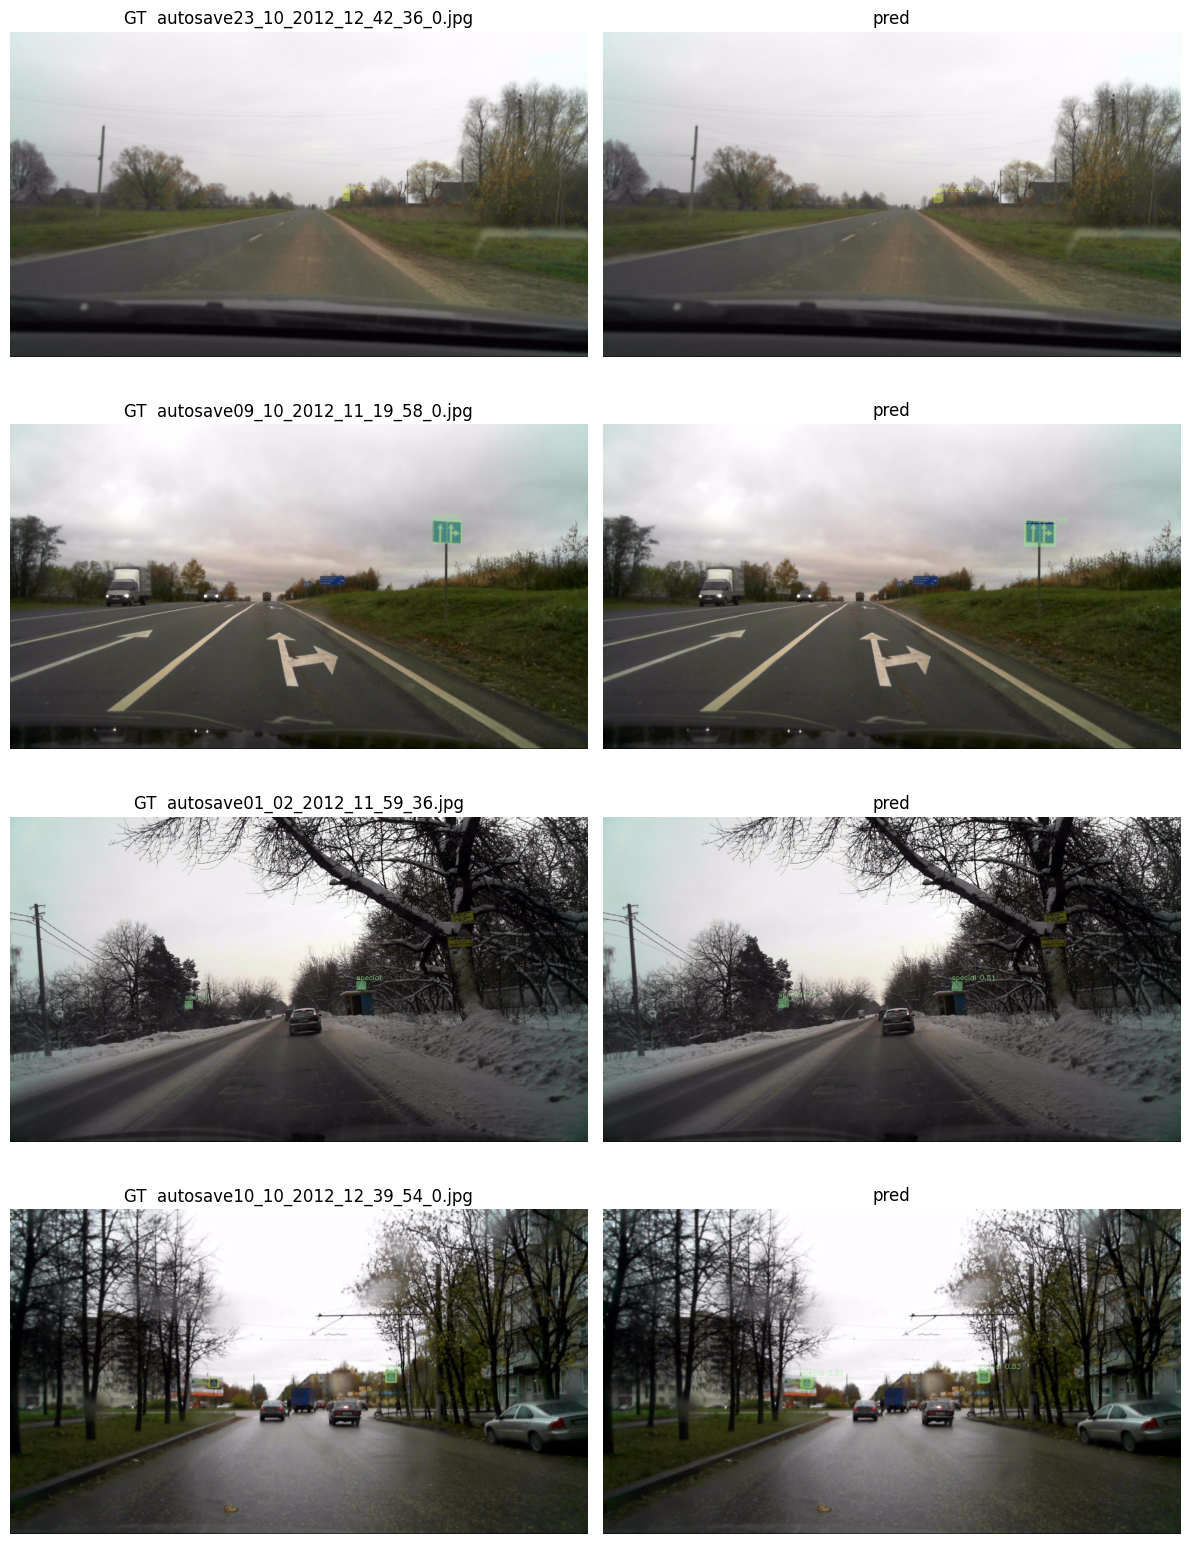

In [13]:
def overlay(img_rgb, masks, classes, scores=None, alpha=0.45):
    palette = np.random.default_rng(123).integers(60, 255, size=(NUM_CLASSES, 3), dtype=np.int32)
    out = img_rgb.copy()
    for k, (m, c) in enumerate(zip(masks, classes)):
        color = palette[c % NUM_CLASSES]
        layer = out.copy(); layer[m] = color
        out = cv2.addWeighted(out, 1 - alpha, layer, alpha, 0)
        ys, xs = np.where(m)
        if len(xs):
            x0, y0 = int(xs.min()), int(ys.min())
            label = SUPER_NAMES[c] if 0 <= c < NUM_CLASSES else f'cls{c}'
            if scores is not None and k < len(scores):
                label += f' {scores[k]:.2f}'
            cv2.putText(out, label, (x0, max(15, y0 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(int(v) for v in color), 1)
    return out


val_imgs_paths = sorted(glob.glob(str(YOLO_DIR/'images'/'val'/'*.jpg')) + glob.glob(str(YOLO_DIR/'images'/'val'/'*.png')))
if val_imgs_paths:
    sample = random.Random(42).sample(val_imgs_paths, min(4, len(val_imgs_paths)))
    fig, axes = plt.subplots(len(sample), 2, figsize=(12, 4 * len(sample)))
    if len(sample) == 1:
        axes = axes.reshape(1, 2)
    for r, ip in enumerate(sample):
        img_rgb = cv2.imread(ip)[:, :, ::-1]
        H, W = img_rgb.shape[:2]
        gt_m, gt_c = load_yolo_seg_gt(YOLO_DIR/'labels'/'val'/f'{Path(ip).stem}.txt', H, W)
        pr_m, pr_c, pr_s, _ = predict_masks(best_model, ip)
        axes[r, 0].imshow(overlay(img_rgb, gt_m, gt_c)); axes[r, 0].set_title(f'GT  {Path(ip).name}'); axes[r, 0].axis('off')
        axes[r, 1].imshow(overlay(img_rgb, pr_m, pr_c, pr_s)); axes[r, 1].set_title('pred'); axes[r, 1].axis('off')
    plt.tight_layout(); plt.show()

found 11 photo(s)


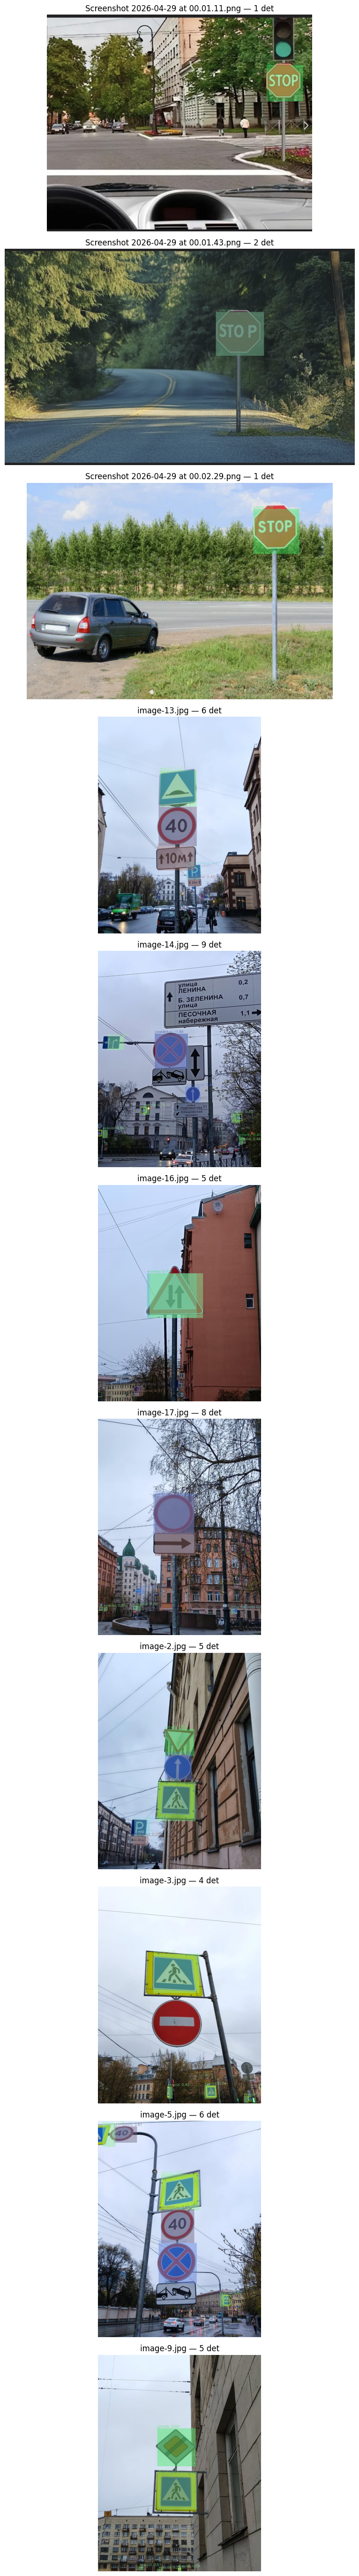

no GT annotations — qualitative inference only


In [14]:
real_imgs = sorted(sum(([str(p) for p in REAL_DIR.glob(f'*{ext}')] for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']), []))
real_metrics = None

if not real_imgs:
    print(f'[skip] no photos in {REAL_DIR}')
else:
    print(f'found {len(real_imgs)} photo(s)')
    real_lbl_dir = REAL_DIR / 'labels'; real_lbl_dir.mkdir(exist_ok=True)
    real_have_gt = 0
    for ip in real_imgs:
        out_txt = real_lbl_dir / (Path(ip).stem + '.txt')
        existing_txt = Path(ip).with_suffix('.txt')
        if existing_txt.exists():
            shutil.copy2(existing_txt, out_txt)
            if out_txt.stat().st_size > 0:
                real_have_gt += 1
        elif not out_txt.exists():
            out_txt.write_text('')

    pred_dir = REAL_DIR / 'predictions'; pred_dir.mkdir(exist_ok=True)
    n = len(real_imgs)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))
    if n == 1:
        axes = [axes]
    for i, ip in enumerate(real_imgs):
        img_rgb = cv2.imread(ip)[:, :, ::-1]
        pr_m, pr_c, pr_s, _ = predict_masks(best_model, ip)
        vis = overlay(img_rgb, pr_m, pr_c, pr_s)
        cv2.imwrite(str(pred_dir/Path(ip).name), vis[:, :, ::-1])
        axes[i].imshow(vis); axes[i].set_title(f'{Path(ip).name} — {len(pr_m)} det'); axes[i].axis('off')
    plt.tight_layout(); plt.show()

    if real_have_gt > 0:
        real_metrics = evaluate(best_model, REAL_DIR, real_lbl_dir, NUM_CLASSES, require_gt=True)
        for k, v in real_metrics.items():
            print(f'  {k:>20}: {v}')
    else:
        print('no GT annotations — qualitative inference only')

In [15]:
results = {
    'task': 'instance_segmentation_8_road_sign_categories',
    'dataset': 'RTSD (MSU Graphics) — 8 super-classes by ПДД category',
    'super_classes': SUPER_NAMES,
    'super_classes_ru': SUPER_RU,
    'mask_strategy': 'bbox_rectangle',
    'model': 'YOLO11s-seg (pretrained COCO, fine-tuned)',
    'num_classes': NUM_CLASSES,
    'train_size': tr_ok,
    'val_size': va_ok,
    'train_instances': tr_inst,
    'val_instances': va_inst,
    'hyperparameters': {
        'imgsz': IMG_SIZE, 'batch': BATCH, 'epochs': EPOCHS, 'patience': PATIENCE,
        'save_period': SAVE_PERIOD, 'optimizer': 'auto', 'amp': True, 'cache': 'disk',
        'device': str(device),
    },
    'training_seconds': round(training_seconds, 1),
    'training_minutes': round(training_seconds / 60, 1),
    'best_weights': str(best_pt),
    'ultralytics_metrics': {
        'box_mAP50': round(float(val_metrics.box.map50), 4),
        'box_mAP50_95': round(float(val_metrics.box.map), 4),
        'mask_mAP50': round(float(val_metrics.seg.map50), 4),
        'mask_mAP50_95': round(float(val_metrics.seg.map), 4),
    },
    'custom_metrics_val': val_custom,
    'custom_metrics_real_photos': real_metrics,
}
RESULTS_PATH.write_text(json.dumps(results, indent=2, ensure_ascii=False))
print(json.dumps(results, indent=2, ensure_ascii=False))

{
  "task": "instance_segmentation_8_road_sign_categories",
  "dataset": "RTSD (MSU Graphics) — 8 super-classes by ПДД category",
  "super_classes": [
    "warning",
    "priority",
    "prohibitory",
    "mandatory",
    "special",
    "informational",
    "service",
    "additional"
  ],
  "super_classes_ru": [
    "Предупреждающие",
    "Приоритета",
    "Запрещающие",
    "Предписывающие",
    "Особых_предписаний",
    "Информационные",
    "Сервиса",
    "Доп_информации"
  ],
  "mask_strategy": "bbox_rectangle",
  "model": "YOLO11s-seg (pretrained COCO, fine-tuned)",
  "num_classes": 8,
  "train_size": 30000,
  "val_size": 1500,
  "train_instances": 52735,
  "val_instances": 2730,
  "hyperparameters": {
    "imgsz": 640,
    "batch": 16,
    "epochs": 80,
    "patience": 20,
    "save_period": 3,
    "optimizer": "auto",
    "amp": true,
    "cache": "disk",
    "device": "0"
  },
  "training_seconds": 24693.5,
  "training_minutes": 411.6,
  "best_weights": "/mnt/data/itmo-cv/lab-